# Uttar Pradesh Crime Data Analysis

This dataset captures the crime data across major cities of Uttar Pradesh in
India. The cities are Ghaziabad, Lucknow and Kanpur. Data description as follows:
1. City                            = City of crime

2. Title                           = Summary of the crime
3. Text                            = Crime description in detail
4. Murder happened with reason     = Crimes which resulted in murder and the reason
                                   1:Property/Land Disputes,
                                   2:Family Dispute
                                   3:Petty Quarrels,
                                   4:Money Disputes, 
                                   5:Personal Vendetta, 
                                   6:Love Affairs, 
                                   7:Casteism
                                   8: Unknown/other

5. Number of child victims         = Number of child victims in the crime
6. Number of male victims(adult)`  = Number of adult male victims in the crime
7. Number of female victims(adult)`= Number of adult female vcitims in the crime
8. Kidnnaping:Number of child victims = Number of child victims of kidnapping
9. Number of male(adult)           = Number of adult males in the crime
10. Number of female(adult)         = Number of adult females in the crime
11. Crime Against Women ( Combined )= Crime against women along with reason and relevant IPC section
                                   1. Murder with Rape 
                                   2. Dowry Deaths(Sec. 3048)
                                   3. Suicide(sec 305/306)
                                   4. Kidnapping(All)
                                   5. Acid Attack(Sec. 326A IPC)
                                   6. Cruelty by Husband/in-laws((Sec.498 A IPC)
                                   7. Rape only(Sec. 376 or 511 IPC)
                                   8. Assault on Women with Intent to Outrage her Modesty (Sec. 354 IPC)
                                   9. Cyber Crimes against Women
                                   10. Protection of Children from Sexual Offences Act` = 
12. Number of adult victims`        = Number of adult victims including males and females
13. Number of childs invoved        = Number of child involved in the crime including the perpetrator and the victim

# Environment setup and importing data

In [1]:
library(tidyverse)
library(lubridate)
library(stringr)
library(forcats)
library(tidyquant)
library(readxl)

# Read the data ----

data_tbl <- read_csv("../input/up-crime-data-year-2019/MR data - Compiled Data Set.csv")

# The data has somewhat descriptive column names which would make it difficult to 
# refer in the code later. str() also gives a large output, to get a clearer idea of the structure of the data,
# use the glimpse() function.

# str(data_tbl)
glimpse(data_tbl)

# The data has 466 rows and 13 column variables.

── Attaching packages ─────────────────────────────────────── tidyverse 1.3.0 ──

✔ ggplot2 3.3.3     ✔ purrr   0.3.4
✔ tibble  3.1.1     ✔ dplyr   1.0.5
✔ tidyr   1.1.3     ✔ stringr 1.4.0
✔ readr   1.4.0     ✔ forcats 0.5.0

── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()


Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union


Loading required package: PerformanceAnalytics

Loading required package: xts

Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric



Attaching package: ‘xts’


The following objects are masked from ‘package:dplyr’:

    first, last



Attaching package: ‘PerformanceAnalytics’


The following object is masked from ‘package:graphics’:

    legend


Loading required package: quantmod

Loading re

Rows: 466
Columns: 13
$ City                                                                                                                                                                                                                                                                                                                                                                                                           <chr> …
$ Title                                                                                                                                                                                                                                                                                                                                                                                                          <chr> …
$ Text                                                                                                                                                          

**Wrangle Data for easy readability as well as to assist in referencing later on.**

In [2]:
# Data wrangling ----
# Renaming the columns to make it more readable 

data_wrangled_tbl <- data_tbl %>%
    rename(Crime_Summary               = Title,
           Crime_Description           = Text,
           IsMurder_And_Reason         = contains("Murder Happened"),
           No_of_Child_Victims         = starts_with("Number of child victims"),
           No_of_Male_Victims_Adult    = contains("Number of male victims"),
           No_of_Female_victims_Adult  = contains("Number of female victims"),
           Child_victims_of_kidnapping = starts_with("Kidnnaping"),
           No_of_males                 = contains("Number of male(adult)"),
           No_of_females               = contains("Number of female(adult)"),
           Crime_against_women_type    = contains("Crime Against Women")
           ) %>%
    set_names(names(.) %>% str_replace_all(" ","_") %>% str_to_title()) %>%
    
 
# Adding a column which flags the most frequent crimes with some keywords in the crime 
# summary column
    mutate(Crime_type = case_when(
        str_detect(str_to_lower(Crime_summary),c("molest","harass")) ~ "Molestation",
        str_detect(str_to_lower(Crime_summary),c("rob","robbed",
                    "burglar","burglars","extort","extortion",
                    "dowry","loot","looted"))                        ~ "Robbery",
        str_detect(str_to_lower(Crime_summary),c("rape","raped",
                                                 "raping","rapes"))  ~ "Rape",
        str_detect(str_to_lower(Crime_summary), c("kills self",
                    "suicide","hanged","hangs"))                     ~ "Suicide",
        str_detect(str_to_lower(Crime_summary), c("fraud"))          ~ "Fraud",
        str_detect(str_to_lower(Crime_summary),c("kidnapped",
                    "abducted","kidnap","kidnaps","abducted",
                    "abducting","abducts"))                          ~ "Kidnapping",
                   
        TRUE                                                         ~ "Other Crimes"
    )
    ) %>%
 
# Creating an additional flag Is_Murder in cases where crime has led to murder
    mutate(Is_Murder = case_when(
        is.na(Ismurder_and_reason) == TRUE ~ 0,
        TRUE ~ 1
    )) %>%
 
# Some columns in Crime against women type have 2 charges (and separate provisions of IPC against
# the criminal), separating it to 2 columns for easy analysis

    separate(Crime_against_women_type, 
             into = c("Crime_against_women_type1","Crime_against_women_type2"),
             sep  = ",") %>%

# Converting the columns into factors for easier analysis and visualisation later on

    mutate(Crime_against_women_type1 = Crime_against_women_type1 %>% as_factor() %>% fct_inseq(),
           Crime_against_women_type2 = Crime_against_women_type2 %>% as_factor() %>% fct_inseq()
           ) %>%
   
# In some cases, crime is reported in a different city than the city of crime occurence

    separate(Crime_description, into = c("Reported_city","Crime_Description"), sep = ":") %>%
    mutate(Reported_city = str_to_title(Reported_city))

glimpse(data_wrangled_tbl)

Warning message in stri_detect_regex(string, pattern, negate = negate, opts_regex = opts(pattern)):
“longer object length is not a multiple of shorter object length”
Warning message in stri_detect_regex(string, pattern, negate = negate, opts_regex = opts(pattern)):
“longer object length is not a multiple of shorter object length”
Warning message in stri_detect_regex(string, pattern, negate = negate, opts_regex = opts(pattern)):
“longer object length is not a multiple of shorter object length”
Warning message in stri_detect_regex(string, pattern, negate = negate, opts_regex = opts(pattern)):
“longer object length is not a multiple of shorter object length”
Warning message:
“Expected 2 pieces. Additional pieces discarded in 7 rows [50, 79, 116, 118, 130, 181, 392].”
Warning message:
“Expected 2 pieces. Missing pieces filled with `NA` in 132 rows [7, 8, 14, 23, 26, 30, 36, 45, 49, 51, 55, 59, 64, 74, 75, 76, 77, 81, 83, 84, ...].”
Warning message:
“Expected 2 pieces. Additional pieces dis

Rows: 466
Columns: 17
$ City                        <chr> "Ghaziabad", "Ghaziabad", "Ghaziabad", "Gh…
$ Crime_summary               <chr> "Minor molests mute girl, sent to observat…
$ Reported_city               <chr> "Ghaziabad", "Ghaziabad", "Ghaziabad", "Gh…
$ Crime_Description           <chr> " A 12-year-old boy was sent to an observa…
$ Ismurder_and_reason         <chr> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, "M…
$ No_of_child_victims         <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, 1,…
$ No_of_male_victims_adult    <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA…
$ No_of_female_victims_adult  <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA…
$ Child_victims_of_kidnapping <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA…
$ No_of_males                 <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA…
$ No_of_females               <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA…
$ Crime_against_women_type1   <fct> 8, NA, NA, NA, NA, NA, 10, 9, NA, NA, NA, …
$ Crime_against_wo

# Summarizing Data to get some insights

Most of the columns have NA data, data seems to have some missing values in # of child victims,
number of adult victims and others. Limiting the analysis to find out the distribution of crime 
across major cities, crime types across these cities, murder rates across these cities,
murder reasons across major cities, crime agaisnt women and distribution across these cities and 
finally, safest city for women from amongst these 3 cities for which the data is published.
The analysis can be extended likewise to find the safest city for children.

In [3]:

# Total crime in the cities

Total_crime_citywise <- data_wrangled_tbl %>%
    select(City) %>%
    group_by(City) %>%
    summarise(Total_crime_citywise = n(),
              Percent_crime_citywise = n()/nrow(.),
              Percent_crime_citywise_chr = scales::percent(Percent_crime_citywise,trim = TRUE)) %>%
    ungroup()
Total_crime_citywise


City,Total_crime_citywise,Percent_crime_citywise,Percent_crime_citywise_chr
<chr>,<int>,<dbl>,<chr>
Ghaziabad,167,0.3583691,36%
Kanpur,97,0.2081545,21%
Lucknow,202,0.4334764,43%


`summarise()` has grouped output by 'City'. You can override using the `.groups` argument.



City,Crime_type,Number_of_crime_instances,Percent_of_total_crime_in_city_chr
<chr>,<chr>,<int>,<chr>
Ghaziabad,Fraud,2,1.20%
Ghaziabad,Kidnapping,2,1.20%
Ghaziabad,Molestation,12,7.19%
Ghaziabad,Rape,5,2.99%
Ghaziabad,Robbery,4,2.40%
Ghaziabad,Suicide,2,1.20%
Kanpur,Kidnapping,2,2.1%
Kanpur,Molestation,3,3.1%
Kanpur,Rape,6,6.2%


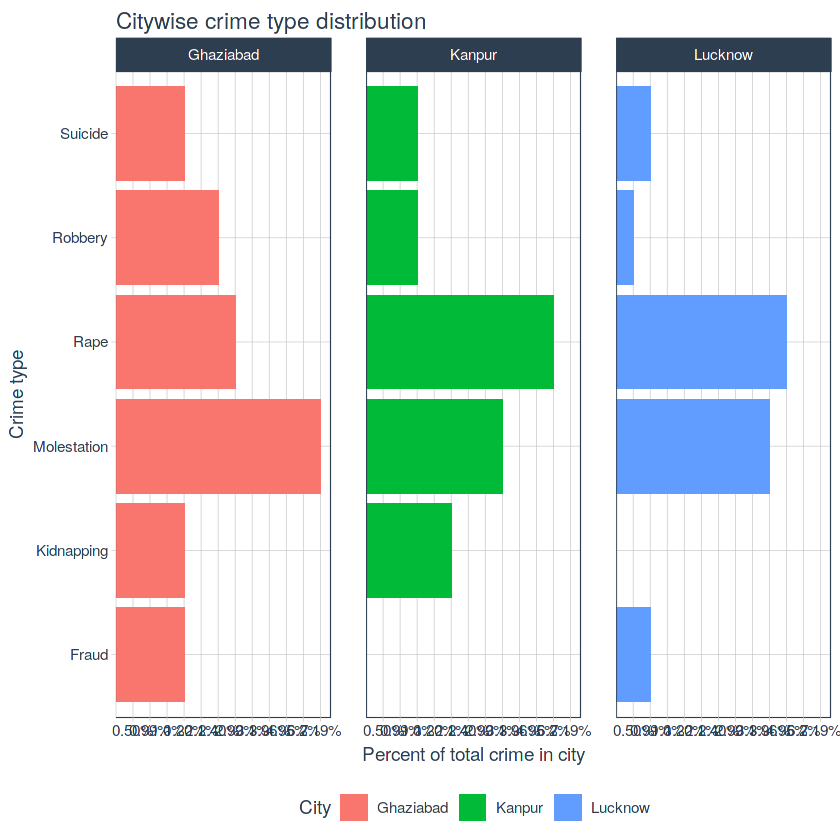

In [4]:
# Distribition of major crimes across cities

Crime_type_distribution <- data_wrangled_tbl %>%
    select(City, Crime_type) %>%
    group_by(City,Crime_type) %>%
    summarise(Number_of_crime_instances = n()) %>%
    ungroup() %>%
    group_by(City) %>%
    mutate(Percent_of_total_crime_in_city = Number_of_crime_instances/sum(Number_of_crime_instances)) %>%
    mutate(Percent_of_total_crime_in_city_chr = scales::percent(Percent_of_total_crime_in_city, trim = TRUE)) %>%
    ungroup() %>%
    select(-Percent_of_total_crime_in_city) %>%
    filter(!(Crime_type == "Other Crimes"))

Crime_type_distribution

Crime_type_distribution %>%
    ggplot(aes(Crime_type,Percent_of_total_crime_in_city_chr, fill = City)) +
    geom_col()+
    theme_tq()+
    scale_color_tq()+
    facet_wrap(~City)+
    coord_flip()+
    labs(title = "Citywise crime type distribution",
         x = "Crime type",
         y = "Percent of total crime in city")

In [5]:

# Total crimes leading to murder citywise


Total_crime_leading_to_murder_citywise <- data_wrangled_tbl%>%
    select(City,Is_Murder) %>%
    group_by(City) %>%
    summarise(Total_crime = n(),
              Total_crime_with_murder = sum(Is_Murder),
              Murder_percent = Total_crime_with_murder/Total_crime,
              Murder_percent_chr = scales::percent(Murder_percent, trim = TRUE)
              ) %>%
    ungroup()
Total_crime_leading_to_murder_citywise 

message("Kanpur has the highest instance of crimes leading to murder. Can be termed as the most violent city!!")

City,Total_crime,Total_crime_with_murder,Murder_percent,Murder_percent_chr
<chr>,<int>,<dbl>,<dbl>,<chr>
Ghaziabad,167,47,0.2814371,28%
Kanpur,97,37,0.3814433,38%
Lucknow,202,63,0.3118812,31%


Kanpur has the highest instance of crimes leading to murder. Can be termed as the most violent city!!



`summarise()` has grouped output by 'City'. You can override using the `.groups` argument.



City,Ismurder_and_reason,Citywise_murder_reason,Citywise_murder_reason_percent,Citywise_murder_reason_percent_chr
<chr>,<chr>,<int>,<dbl>,<chr>
Ghaziabad,Family Dispute,9,0.061224490,6%
Ghaziabad,Love Affairs,6,0.040816327,4%
Ghaziabad,Money Disputes,3,0.020408163,2%
Ghaziabad,Personal Vendetta,2,0.013605442,1%
Ghaziabad,Petty Quarrels,11,0.074829932,7%
Ghaziabad,Property Disputes,4,0.027210884,3%
Ghaziabad,Unknown reasons,12,0.081632653,8%
Kanpur,Casteism,1,0.006802721,1%
Kanpur,Family Dispute,4,0.027210884,3%


In Ghaziabad, petty quarrels have more probablity of leading to murder

Warning message:
“Don't get into any quarrel over petty issues in Ghaziabad!!”
In Kanpur, falling in love can be fatal given the high murder instances

Lucknow too has 16% of murder reasons being love affairs.



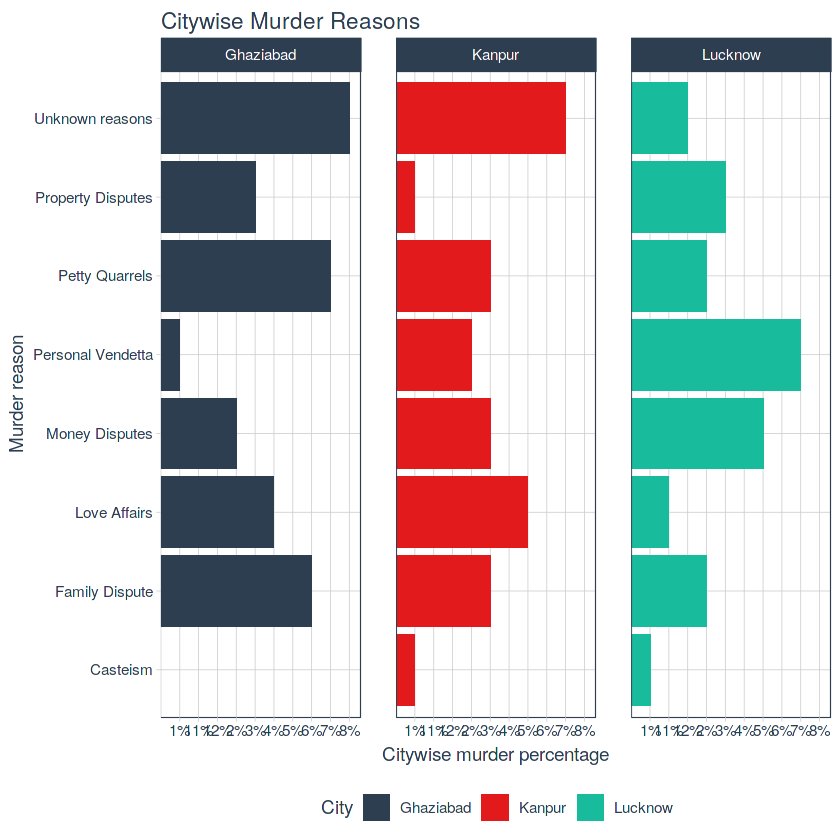

In [6]:
# Let's get deeper into the murder reasons across major cities

Murder_reasons_citywise <- data_wrangled_tbl %>%
    filter(!is.na(Ismurder_and_reason)) %>%
    group_by(City,Ismurder_and_reason) %>%
    summarise(Citywise_murder_reason = n(),
              Citywise_murder_reason_percent = n()/nrow(.),
              Citywise_murder_reason_percent_chr = scales::percent(Citywise_murder_reason_percent, trim = TRUE)) %>%
    ungroup()

Murder_reasons_citywise
    
Murder_reasons_citywise %>%
    ggplot(aes(x = Ismurder_and_reason, y = Citywise_murder_reason_percent_chr, fill = City))+
    geom_col() +
    coord_flip()+
    facet_wrap(~City)+
    theme_tq()+
    scale_fill_tq()+
    
    labs(title = "Citywise Murder Reasons",
         x = "Murder reason",
         y = "Citywise murder percentage")

message("In Ghaziabad, petty quarrels have more probablity of leading to murder")
warning("Don't get into any quarrel over petty issues in Ghaziabad!!", call. = FALSE)

message("In Kanpur, falling in love can be fatal given the high murder instances")
message("Lucknow too has 16% of murder reasons being love affairs.")




City,Total_crime_against_women,Total_crime,Percent_crime_against_women_chr
<chr>,<int>,<int>,<chr>
Ghaziabad,70,167,41.92%
Kanpur,47,97,48.45%
Lucknow,83,202,41.09%


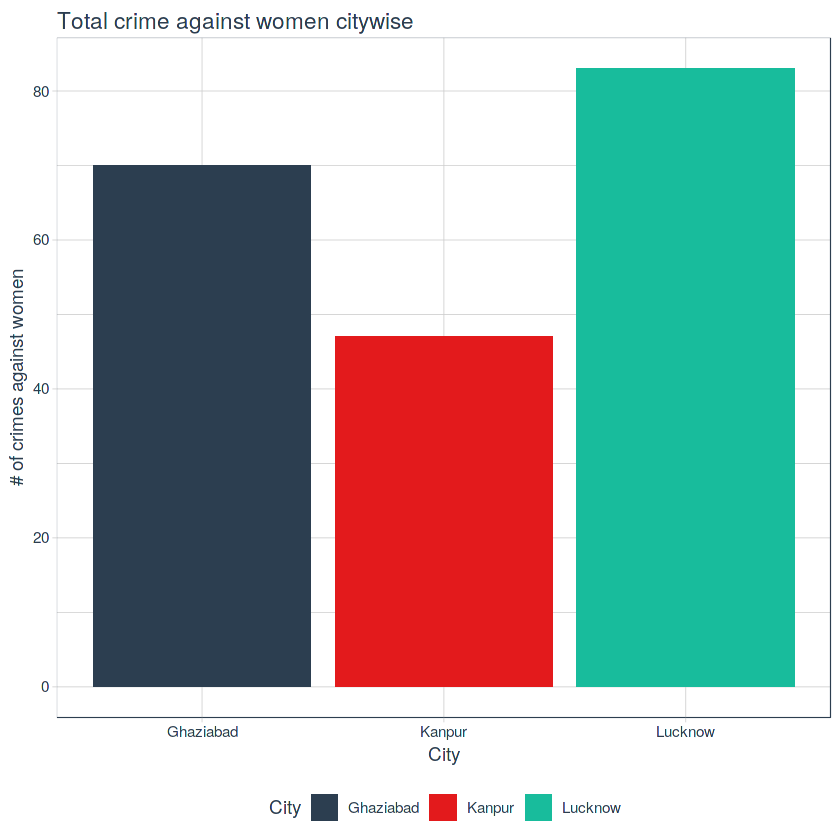

While percentage wise, Kanpur has more crime against women in comparison to other
         cities, but Lucknow and Ghaziabad have more number of crimes as well as more 
         instances of crime against women.



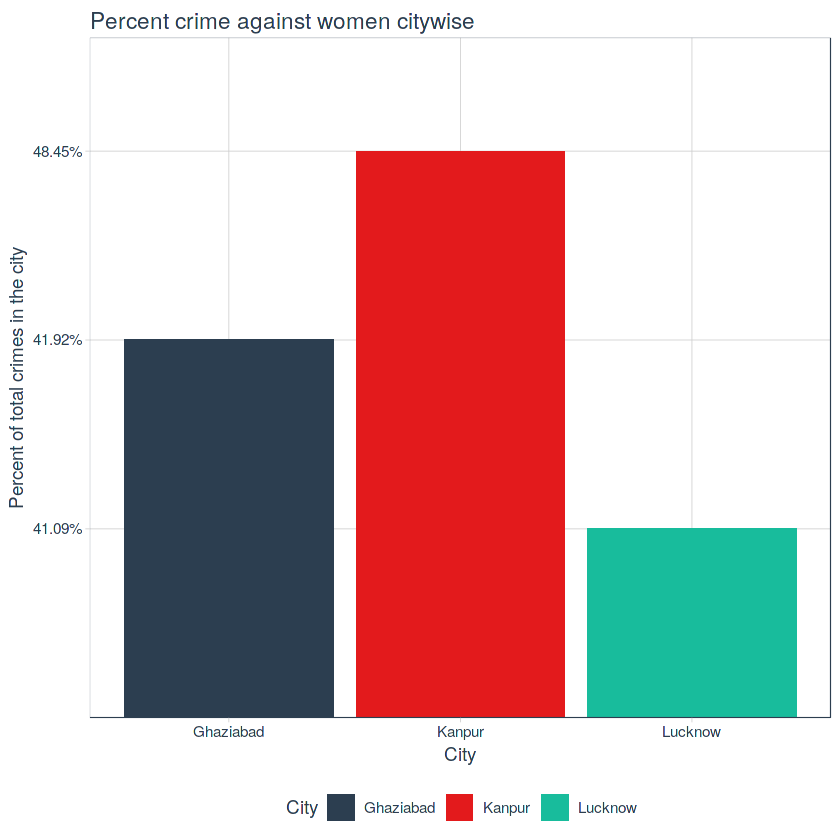

In [7]:
# Let's check the distribution of crimes agaisnt women along with the type of charge as 
# per IPC
Crime_against_women_citywise <- data_wrangled_tbl %>%
    select(City,Crime_against_women_type1,Crime_against_women_type2) %>%
    filter(!is.na(Crime_against_women_type1)) %>%
    group_by(City) %>%
    summarise(Total_crime_against_women = n() ) %>%
    ungroup() %>%
    mutate(Total_crime = Total_crime_citywise$Total_crime_citywise) %>%
    mutate(Percent_crime_against_women = Total_crime_against_women/Total_crime) %>%
    mutate(Percent_crime_against_women_chr = scales::percent(Percent_crime_against_women)) %>%
    select(-Percent_crime_against_women)

Crime_against_women_citywise

Crime_against_women_citywise %>%
    ggplot(aes(City,Total_crime_against_women, fill = City))+
    geom_col()+
    theme_tq()+
    scale_fill_tq()+
    labs(title = "Total crime against women citywise",
         y = "# of crimes against women")

Crime_against_women_citywise %>%
    ggplot(aes(City,Percent_crime_against_women_chr, fill = City))+
    geom_col()+
    theme_tq()+
    scale_fill_tq()+
    labs(title = "Percent crime against women citywise",
         y = "Percent of total crimes in the city")

message("While percentage wise, Kanpur has more crime against women in comparison to other
         cities, but Lucknow and Ghaziabad have more number of crimes as well as more 
         instances of crime against women.")

`summarise()` has grouped output by 'City'. You can override using the `.groups` argument.



City,Crime_against_women_type1,Total_crime_against_women,Percent_of_all_crime_in_city,Percent_of_all_crime_in_city_chr,Percent_of_crime_against_women,Percent_of_crime_against_women_chr
<chr>,<fct>,<int>,<dbl>,<chr>,<dbl>,<chr>
Ghaziabad,1,4,2.3952096,2.40%,5.714286,5.7%
Ghaziabad,2,14,8.3832335,8.38%,20.000000,20.0%
Ghaziabad,3,3,1.7964072,1.80%,4.285714,4.3%
Ghaziabad,4,2,1.1976048,1.20%,2.857143,2.9%
Ghaziabad,5,2,1.1976048,1.20%,2.857143,2.9%
Ghaziabad,6,5,2.9940120,2.99%,7.142857,7.1%
Ghaziabad,7,17,10.1796407,10.18%,24.285714,24.3%
Ghaziabad,8,17,10.1796407,10.18%,24.285714,24.3%
Ghaziabad,9,3,1.7964072,1.80%,4.285714,4.3%


In Ghaziabad, ~50% of all crimes against women are of rape or with intent to outrage her modesty. Next major reason
         is dowry. Combinedly, these 3 reasons contribute to ~30% of all crimes committed in the city.

In Kanpur, ~50% of all crimes against women are of rape or with intent to outrage her modesty. Both contribute to ~24%
        of all crimes in the city

In Lucknow,~58% of all crimes against women are of rape or with intent to outrage her modesty. Dowry contributes 
         another 10% to this. Combinedly, these 3 factors contribute 69% to all crimes committed agaisnt women in the city and 
         27% of all crimes in the city.
         Another disturbing trend is the suicide cases which contribute a significant 13% of all crimes against women.



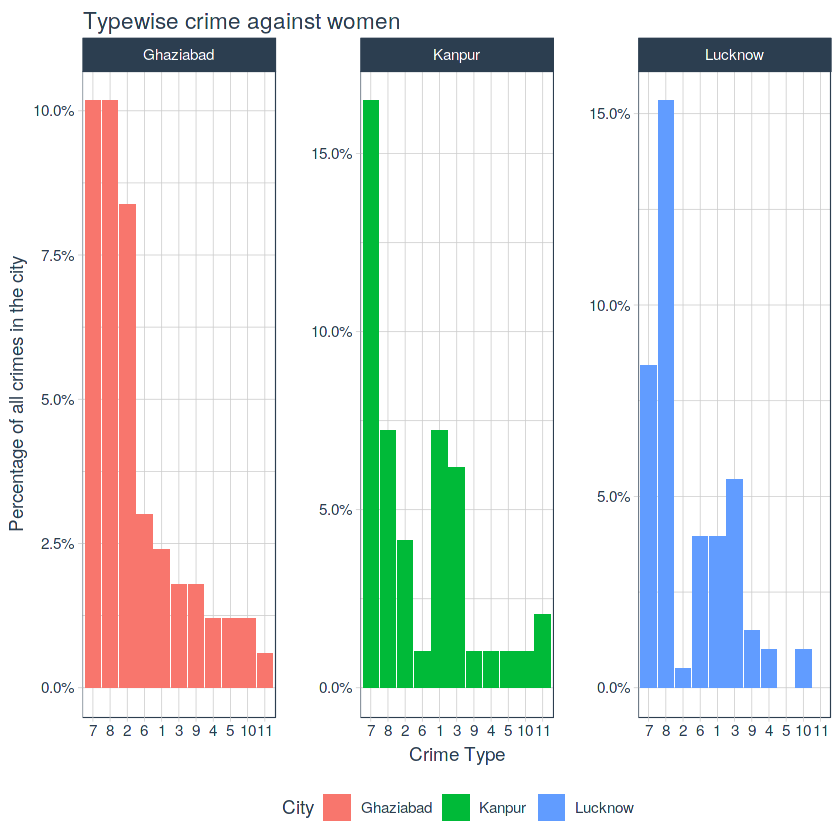

In [8]:
# Now, diving deeper into the crime against women
Crime_against_women_typewise <- data_wrangled_tbl %>%
    select(City,Crime_against_women_type1,Crime_against_women_type2) %>%
    
    group_by(City,Crime_against_women_type1) %>%
    summarise(Total_crime_against_women = n()) %>%
    ungroup() %>%
    group_by(City) %>%
    mutate(Percent_of_all_crime_in_city = (Total_crime_against_women/sum(Total_crime_against_women))*100) %>%
    mutate(Percent_of_all_crime_in_city_chr = scales::number(Percent_of_all_crime_in_city, trim = TRUE, suffix = "%")) %>%
    
    
    filter(!is.na(Crime_against_women_type1)) %>%
    mutate(Percent_of_crime_against_women = (Total_crime_against_women/sum(Total_crime_against_women)*100)) %>%
    mutate(Percent_of_crime_against_women_chr = scales::number(Percent_of_crime_against_women, trim = TRUE, suffix = "%")) %>%
    ungroup() 

Crime_against_women_typewise

Crime_against_women_typewise %>% 
    group_by(City) %>%
    mutate(Crime_against_women_type1 = Crime_against_women_type1 %>% fct_reorder(-Percent_of_all_crime_in_city),
           Crime_againast_women_type1_level = Crime_against_women_type1 %>% as.numeric())%>%
    ungroup() %>%
    ggplot(aes(x = Crime_against_women_type1,Percent_of_all_crime_in_city, fill = City))+
    geom_col() +
    
    theme_tq() +
    scale_color_tq() +
    scale_y_continuous(labels = scales::number_format(suffix = "%"))+
    facet_wrap(~City,scales = "free_y") +
    labs(title = "Typewise crime against women",
         x = "Crime Type",
         y = "Percentage of all crimes in the city")

message("In Ghaziabad, ~50% of all crimes against women are of rape or with intent to outrage her modesty. Next major reason
         is dowry. Combinedly, these 3 reasons contribute to ~30% of all crimes committed in the city.")
message("In Kanpur, ~50% of all crimes against women are of rape or with intent to outrage her modesty. Both contribute to ~24%
        of all crimes in the city")
message("In Lucknow,~58% of all crimes against women are of rape or with intent to outrage her modesty. Dowry contributes 
         another 10% to this. Combinedly, these 3 factors contribute 69% to all crimes committed agaisnt women in the city and 
         27% of all crimes in the city.
         Another disturbing trend is the suicide cases which contribute a significant 13% of all crimes against women.")

In [9]:
# Which city is safest for women OR in other words, which is the most unsafe city of UP?

Crime_against_women_citywise <- data_wrangled_tbl %>%
    select(City,Crime_against_women_type1,Crime_against_women_type2) %>%
    filter(!is.na(Crime_against_women_type1)) %>%
    group_by(City) %>%
    summarise(Total_crime_against_women = n() ) %>%
    ungroup() %>%
    mutate(Total_crime = Total_crime_citywise$Total_crime_citywise) %>%
    mutate(Percent_crime_against_women = Total_crime_against_women/Total_crime,
           Probablity_of_crime_against_women = Percent_crime_against_women*Total_crime_citywise$Percent_crime_citywise) %>%
    mutate(Percent_crime_against_women_chr = scales::percent(Percent_crime_against_women))

Crime_against_women_citywise %>%
select(City,Total_crime, Total_crime_against_women,Probablity_of_crime_against_women) %>%
mutate(Probablity_of_crime_against_women = Probablity_of_crime_against_women %>% scales::number(scale = 100, trim = TRUE, suffix = "%"))

warning("Lucknow is the most unsafe city for women with 17.8% chance that any crime committed in the city will be against women!!
         Next is Ghaziabad!
         Kanpur is the safest amongst the three in terms of women safety.", call. = FALSE)

City,Total_crime,Total_crime_against_women,Probablity_of_crime_against_women
<chr>,<int>,<int>,<chr>
Ghaziabad,167,70,15.0%
Kanpur,97,47,10.1%
Lucknow,202,83,17.8%


Warning message:
“Lucknow is the most unsafe city for women with 17.8% chance that any crime committed in the city will be against women!!
         Next is Ghaziabad!
         Kanpur is the safest amongst the three in terms of women safety.”
